In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pyfluids import HumidAir, InputHumidAir

import sys 
import os
sys.path.append("/home/abharadwaj1/thesis/5_vitrification/utils")
sys.path.append("/home/abharadwaj1/thesis/utils")
from plot_utils import configure_plot_scaling, temporary_rcparams

data_archive_folder = "/home/abharadwaj1/thesis/data_archive/"
input_folder = os.path.join(data_archive_folder, "inputs", "5_vitrification", "comsol")
output_folder = os.path.join(data_archive_folder, "figures_output", "5_vitrification", "temperature_profile_with_air_gap")
assert os.path.exists(output_folder), f"Output folder {output_folder} does not exist."

In [9]:
#alpha_air = 8.58e-6 # m^2/s, from https://www.engineeringtoolbox.com/air-thermal-diffusivity-d_2011.html at 180K and 1 bar
T_initial = 293 # K
T_surface = 80 # K
T_average = (T_initial + T_surface) / 2 # K
print(f"Average temperature: {T_average} K")

# material properties
T_average_C = T_average - 273.15 #Celsius
humid_air = HumidAir().with_state(
    InputHumidAir.pressure(101325),
    InputHumidAir.temperature(T_average_C),
    InputHumidAir.relative_humidity(0.99),
)

k = humid_air.conductivity
density = humid_air.density
cp = humid_air.specific_heat

print(f"Thermal conductivity: {k:.4f} W/(m*K)")
print(f"Density: {density:.4f} kg/m^3")
print(f"Specific heat: {cp:.4f} J/(kg*K)")

thermal_diffusivity = k / (density * cp)
print(f"Thermal diffusivity: {thermal_diffusivity:.4e} m^2/s")

uncertainty_thermal_diffusivity = 0.05 # https://trc.nist.gov/refprop/FAQ/NAO.PDF 

time_start = 0 
time_end = 10e-3 # s
times_array = np.linspace(time_start, time_end, 1000)

reported_values_ccr = [1e5, 1e6, 1e7, 250e3, 220e3, 200e3] # in K/s
min_ccr = min(reported_values_ccr)
max_ccr = max(reported_values_ccr)
mean_ccr = np.mean(reported_values_ccr)

print(f"Minimum reported cooling rate: {min_ccr:.2e} K/s")
print(f"Maximum reported cooling rate: {max_ccr:.2e} K/s")
print(f"Mean reported cooling rate: {mean_ccr:.2e} K/s")
temperature_profile_with_min_ccr = T_initial - times_array * min_ccr
temperature_profile_with_max_ccr = T_initial - times_array * max_ccr
temperature_profile_with_mean_ccr = T_initial - times_array * mean_ccr

temperature_profile_with_min_ccr = np.clip(temperature_profile_with_min_ccr, T_surface, T_initial)
temperature_profile_with_max_ccr = np.clip(temperature_profile_with_max_ccr, T_surface, T_initial)
temperature_profile_with_mean_ccr = np.clip(temperature_profile_with_mean_ccr, T_surface, T_initial)

# temperature_profiles_with_reported_ccr = []
# for ccr in reported_values_ccr:
#     temperature_profile = T_initial - times_array * ccr
#     temperature_profile_clip = np.clip(temperature_profile, T_surface, T_initial)
#     temperature_profiles_with_reported_ccr.append(temperature_profile_clip)

# temperature_profiles_with_reported_ccr = np.array(temperature_profiles_with_reported_ccr)
# lower_bound_temperatures = np.min(temperature_profiles_with_reported_ccr, axis=0)
# upper_bound_temperatures = np.max(temperature_profiles_with_reported_ccr, axis=0)
# mean_temperatures = np.mean(temperature_profiles_with_reported_ccr, axis=0)

Average temperature: 186.5 K
Thermal conductivity: 0.0174 W/(m*K)
Density: 1.8985 kg/m^3
Specific heat: 1007.6233 J/(kg*K)
Thermal diffusivity: 9.0739e-06 m^2/s
Minimum reported cooling rate: 1.00e+05 K/s
Maximum reported cooling rate: 1.00e+07 K/s
Mean reported cooling rate: 1.96e+06 K/s


In [10]:
# effect of air gap on temperature evolution at x=0 
# Equation 3.44, BASIC HEAT AND MASS TRANSFER, A. F. Mills, 3rd edition, page 161
def temperature_evolution_with_air_gap(thickness, times_array, alpha):
    n_start = 0 
    n_final = 1000
    time_constant = thickness**2 / alpha
    
    def series_coefficients(n, x, t):
        fourier_number = t / time_constant
        fractional_length = x / thickness
        order_parameter = 2 * (-1)**n / ((n + 0.5) * np.pi)
        exponential_term = np.exp(-((n + 0.5)**2 * np.pi**2 * fourier_number))
        cosine_term = np.cos((n + 0.5) * np.pi * fractional_length)
        return order_parameter * exponential_term * cosine_term

    def temperature_profile(x, t):
        sum_terms = np.sum([series_coefficients(n, x, t) for n in range(n_start, n_final)])
        #print(f"Sum of series terms for x={x} m, t={t} s: {sum_terms}")
        return T_surface + (T_initial - T_surface) * sum_terms


    temperatures = [temperature_profile(0, t) for t in times_array]
    return temperatures

In [11]:
def temperature_evolution_with_uncertainty(thickness, times_array, alpha, uncertainty_thickness, uncertainty_alpha, n_try=100, ci=95):
    # Calculate the temperature evolution with the given thickness and alpha with uncertainty inclusion
    uncertainty_thickness_real_units = uncertainty_thickness * thickness  # Convert relative uncertainty to absolute
    uncertainty_alpha_real_units = uncertainty_alpha * alpha  # Convert relative uncertainty to absolute
    thickness_distribution = np.random.normal(thickness, uncertainty_thickness_real_units, n_try)
    alpha_distribution = np.random.normal(alpha, uncertainty_alpha_real_units, n_try)
    temperatures = np.zeros((n_try, len(times_array)))
    for i in range(n_try):
        temperatures[i] = temperature_evolution_with_air_gap(thickness_distribution[i], times_array, alpha_distribution[i])
    # Calculate the mean temperature evolution
    temperatures = np.mean(temperatures, axis=0)
    std_temperatures = np.std(temperatures, axis=0)
    # Calculate the uncertainty bounds
    uncertainty_temperatures = 1.96 * std_temperatures / np.sqrt(n_try)  # 95% CI

    
    return temperatures, uncertainty_temperatures

In [12]:
from tqdm import tqdm
temperature_profiles = {}
cooling_rates = {}
#gap_thickness_range = np.linspace(5e-6, 100e-6, 20) # from 1 micron to 100 microns

air_gap_total = {
    "cryochip": 290e-6,
    "cryosilico" : 621e-6,
    "si_old_chip": 872e-6,
    "autogrid": 993e-6
}
reference_thickness_half = {
    "cryochip": 50e-6,  # 20 microns
    "cryosilico": 100e-6, # 50 microns
    "si_old_chip": 150e-6, # 100 microns
    "autogrid": 150e-6 # 150 microns
}
gap_thickness = {k : air_gap_total[k] / 2 - reference_thickness_half[k] for k in air_gap_total.keys()}
gap_thickness_range = np.array(list(gap_thickness.values())) # convert to numpy array for easier manipulation
for thickness in tqdm(gap_thickness_range, desc="Calculating temperature profiles for different air gap thicknesses"):
    temperatures = temperature_evolution_with_air_gap(thickness, times_array, thermal_diffusivity)
    temperature_profiles[thickness] = temperatures
    
    derivative = np.gradient(temperatures, times_array)
    derivative = np.abs(derivative)  # Take absolute value to ensure cooling rate is positive
    cooling_rates[thickness] = np.max(derivative)

Calculating temperature profiles for different air gap thicknesses: 100%|██████████| 4/4 [00:12<00:00,  3.19s/it]


In [13]:
crystallisation_temp = 273 # K 
vitrification_temp = 140 # K

In [14]:
# plot temperature evolution for different air gap thicknesses
figsize_mm = (60, 40)
figsize_in = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)  # Convert mm to inches
fontsize = 8
# rcParams = configure_plot_scaling(figsize_mm)
# rcParams['font.size'] = fontsize
# with temporary_rcparams(rcParams):    
#     plt.figure(figsize=figsize_in, dpi=600)
#     for thickness, temperatures_data in temperature_profiles.items():
#         temperatures = temperatures_data
#         plt.plot(times_array * 1e3, temperatures, label=f'{thickness*1e6:.0f} µm')
#     plt.title('Temperature evolution at x=0 with Air Gap Thickness')
#     plt.xlabel('Time (ms)')
#     plt.ylabel('Temperature (K)')
#     # place legend outside the plot
    
#     crystallisation_temp = 273 # K 
#     vitrification_temp = 140 # K
#     plt.axhline(crystallisation_temp, color='red', linestyle='--')
#     plt.axhline(vitrification_temp, color='blue', linestyle='--')
#     # plot the temperature profiles with reported cooling rates in shaded area
#     plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
#     #plt.plot(times_array * 1e3, temperature_profile_with_mean_ccr, color='black', linestyle='-', label='Mean Temperature Profile')
    
#     plt.xlim(-0.5, 10)
#     plt.legend(title='Air Gap Thickness', bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.tight_layout()
#     plt.savefig(os.path.join(output_folder, "temperature_evolution_with_air_gap_minmax_ccr.pdf"), bbox_inches='tight')
    





In [15]:
# Dump results to a dataframe 
import pandas as pd
temperature_profiles_df = pd.DataFrame.from_dict(temperature_profiles,)
temperature_profiles_df.head()
# convert to long form for easier plotting 
temperature_profiles_long = temperature_profiles_df.melt(var_name='air_gap_thickness', value_name='temperature')
temperature_profiles_long.head()
# add times array corresponding to each data point 
temperature_profiles_long['time'] = np.tile(times_array * 1e3, len(temperature_profiles_long) // len(times_array))  # in ms
temperature_profiles_long.head()
# save to csv
temperature_profiles_long.to_csv(os.path.join(output_folder, "temperature_profiles_with_air_gap_temperature_condition.csv"), index=False)

In [16]:
column_names = ["Air Gap Thickness (um)", "Temperature (K)", "Time (ms)"]
temperature_profiles_long["Air Gap Thickness (um)"] = temperature_profiles_long["air_gap_thickness"].apply(lambda x: x*1e6)  # convert to microns
temperature_profiles_long["Temperature (K)"] = temperature_profiles_long["temperature"]
temperature_profiles_long["Time (ms)"] = temperature_profiles_long["time"] # convert to ms
temperature_profiles_long.head()

,air_gap_thickness,temperature,time,Air Gap Thickness (um),Temperature (K),Time (ms)
0,0.000095,292.932200,0.00000,95.0,292.932200,0.00000
1,0.000095,293.000000,0.01001,95.0,293.000000,0.01001
2,0.000095,292.999735,0.02002,95.0,292.999735,0.02002
3,0.000095,292.979923,0.03003,95.0,292.979923,0.03003
4,0.000095,292.819068,0.04004,95.0,292.819068,0.04004


/tmp/ipykernel_4790/2971018589.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


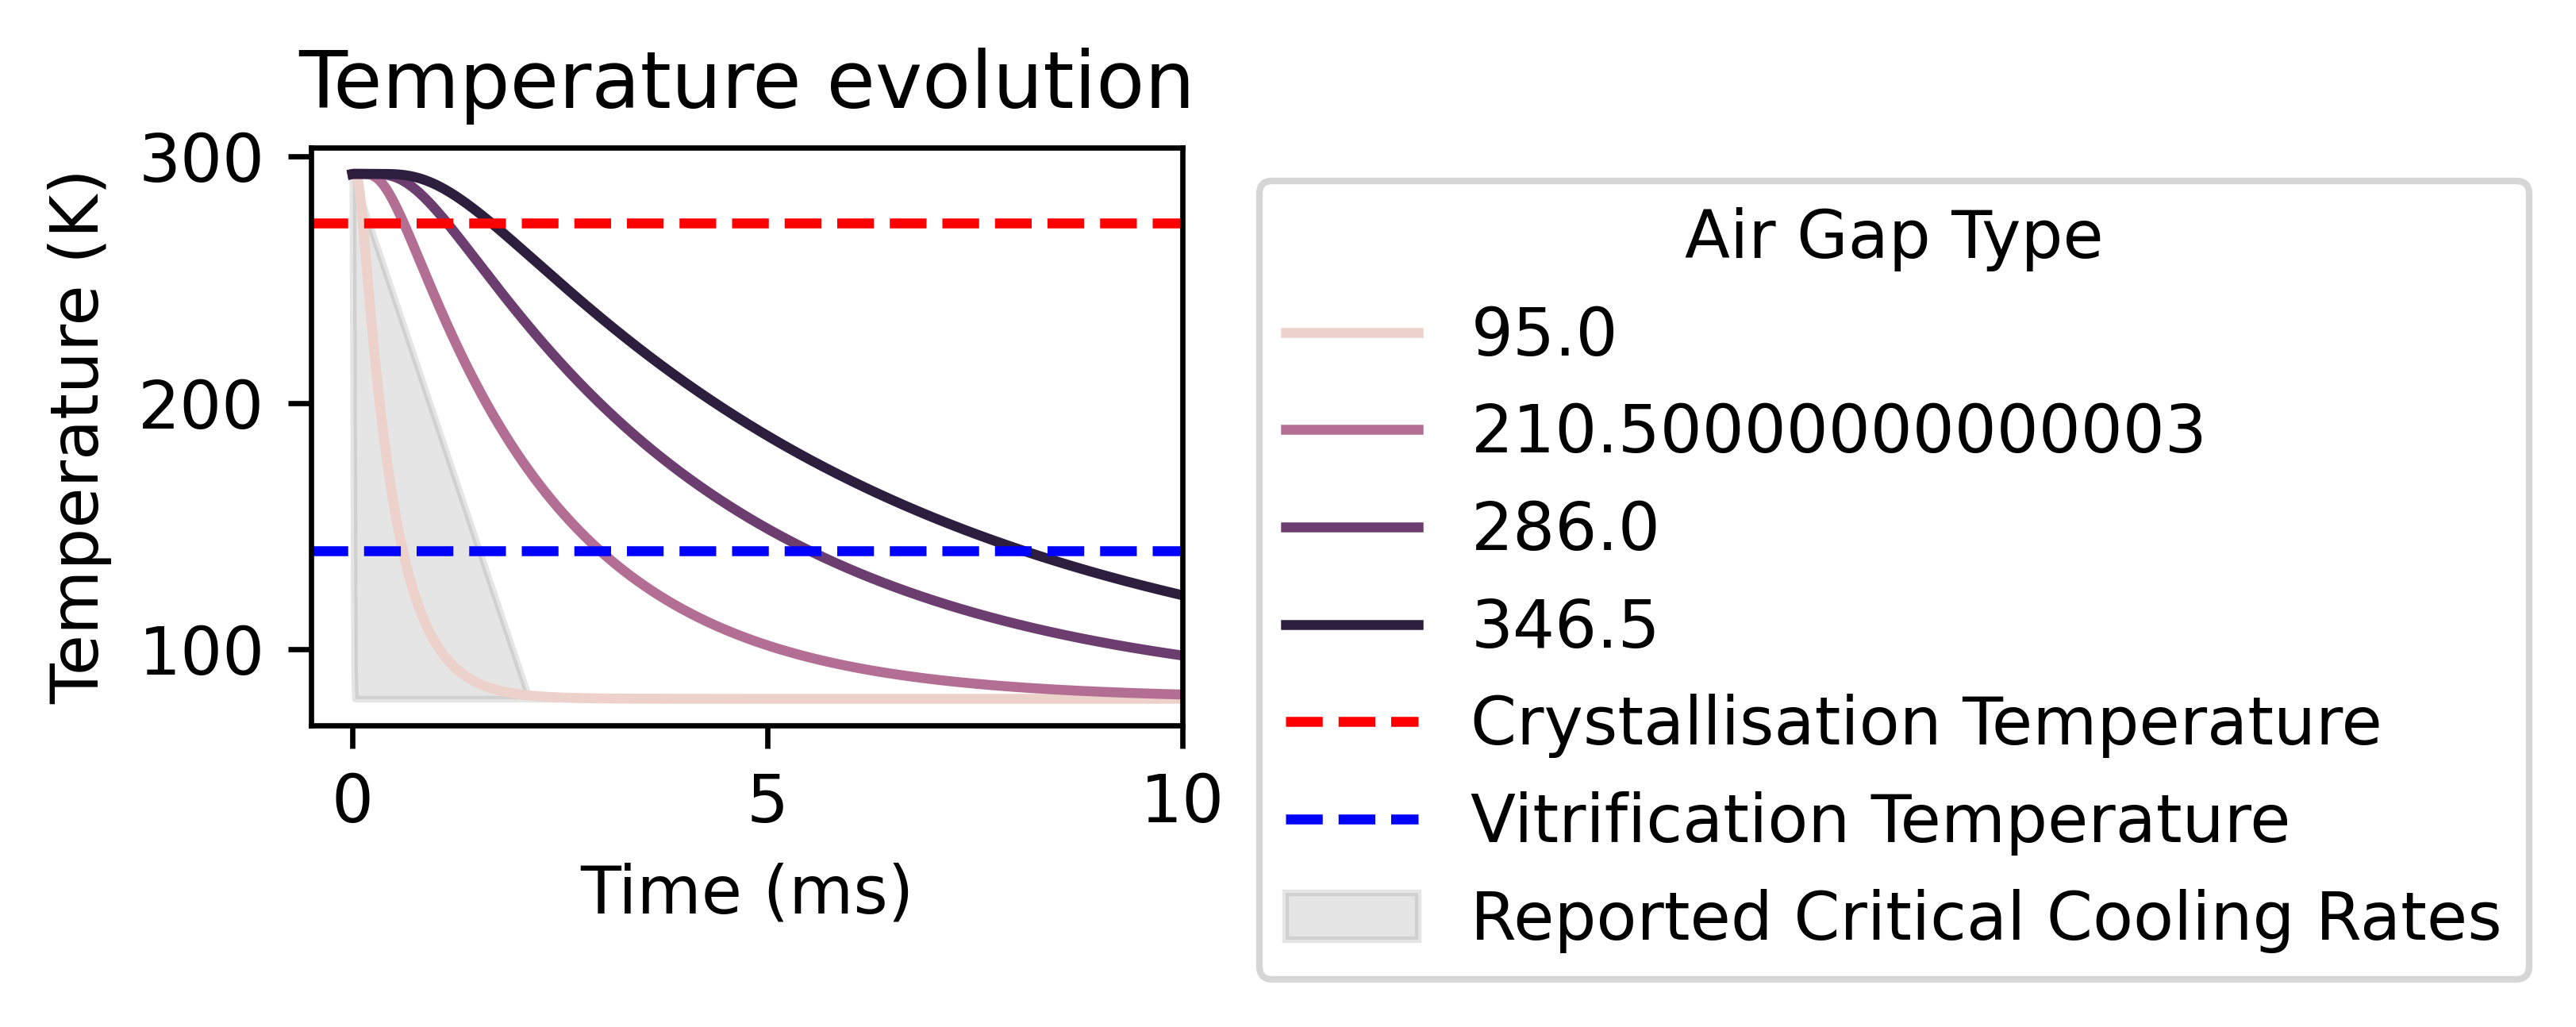

In [17]:
import seaborn as sns

#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
sns.lineplot(data=temperature_profiles_long, x="Time (ms)", y="Temperature (K)", hue='Air Gap Thickness (um)', color='orange')
#sns.lineplot(data=comsol_data_asymmetric, x="Time (ms)", y="Temperature (K)", label='Asymmetric Air Gap', color='purple')

plt.title('Temperature evolution')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
#plt.plot(times_array * 1e3, temperature_profile_with_min_ccr, color='grey', linestyle='-', label='Min Critical Cooling Rate')
#plt.plot(times_array * 1e3, temperature_profile_with_max_ccr, color='grey', linestyle='-', label='Max Critical Cooling Rate')
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.xlim(-0.5, 10)
plt.legend(title='Air Gap Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "temperature_evolution_analytical_temp_bc.pdf"), bbox_inches='tight')

In [18]:
# Now plot temperature evolution obtained using COMSOL 
symmetric_air_gap_file_comsol = os.path.join(input_folder, "symmetric_air_gap10ms.csv")
asymmetric_air_gap_file_comsol = os.path.join(input_folder, "asymmetric_air_gap.csv")
comsol_data_symmetric = pd.read_csv(symmetric_air_gap_file_comsol, sep=",", header=[0])
comsol_data_asymmetric = pd.read_csv(asymmetric_air_gap_file_comsol, sep=",", header=[4])
column_names = ["Air Gap Thickness (um)", "Time (ms)", "Temperature (K)"]
comsol_data_symmetric.columns = column_names
comsol_data_asymmetric.columns = column_names
comsol_data_asymmetric.head()

,Air Gap Thickness (um),Time (ms),Temperature (K)
0,90,0.0,293.117906
1,90,0.1,183.738099
2,90,0.2,130.767316
3,90,0.3,106.063632
4,90,0.4,94.128355


/tmp/ipykernel_4790/2936526628.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


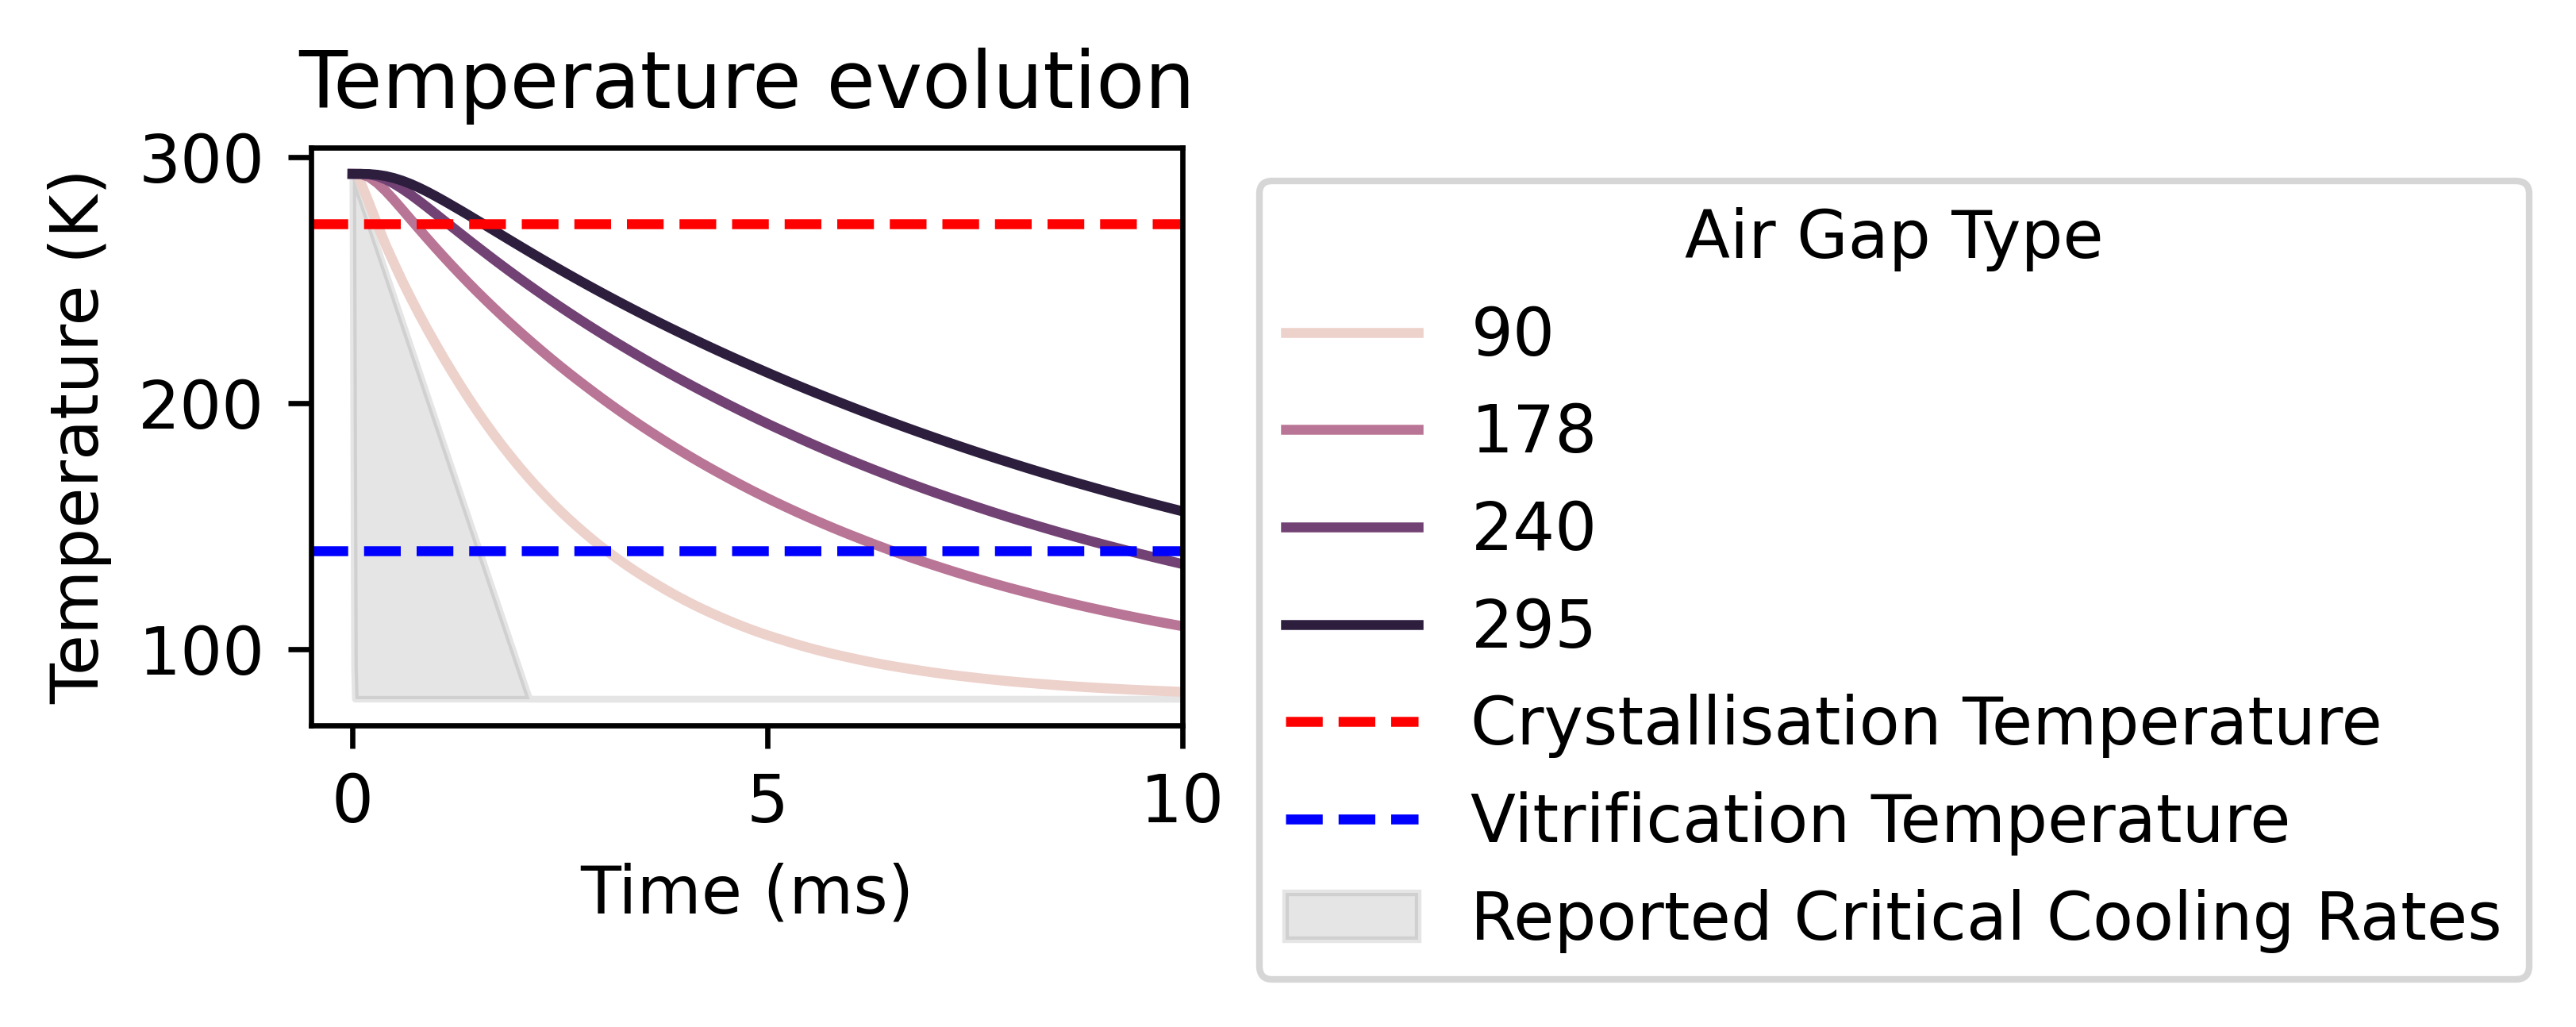

In [19]:
import seaborn as sns
#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
sns.lineplot(data=comsol_data_symmetric, x="Time (ms)", y="Temperature (K)", hue='Air Gap Thickness (um)', color='orange')
#sns.lineplot(data=comsol_data_asymmetric, x="Time (ms)", y="Temperature (K)", label='Asymmetric Air Gap', color='purple')

plt.title('Temperature evolution')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
#plt.plot(times_array * 1e3, temperature_profile_with_min_ccr, color='grey', linestyle='-', label='Min Critical Cooling Rate')
#plt.plot(times_array * 1e3, temperature_profile_with_max_ccr, color='grey', linestyle='-', label='Max Critical Cooling Rate')
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.xlim(-0.5, 10)
plt.legend(title='Air Gap Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(os.path.join(output_folder, "symmetric_temperature_evolution_comsol.pdf"), bbox_inches='tight')

/tmp/ipykernel_4790/843737005.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


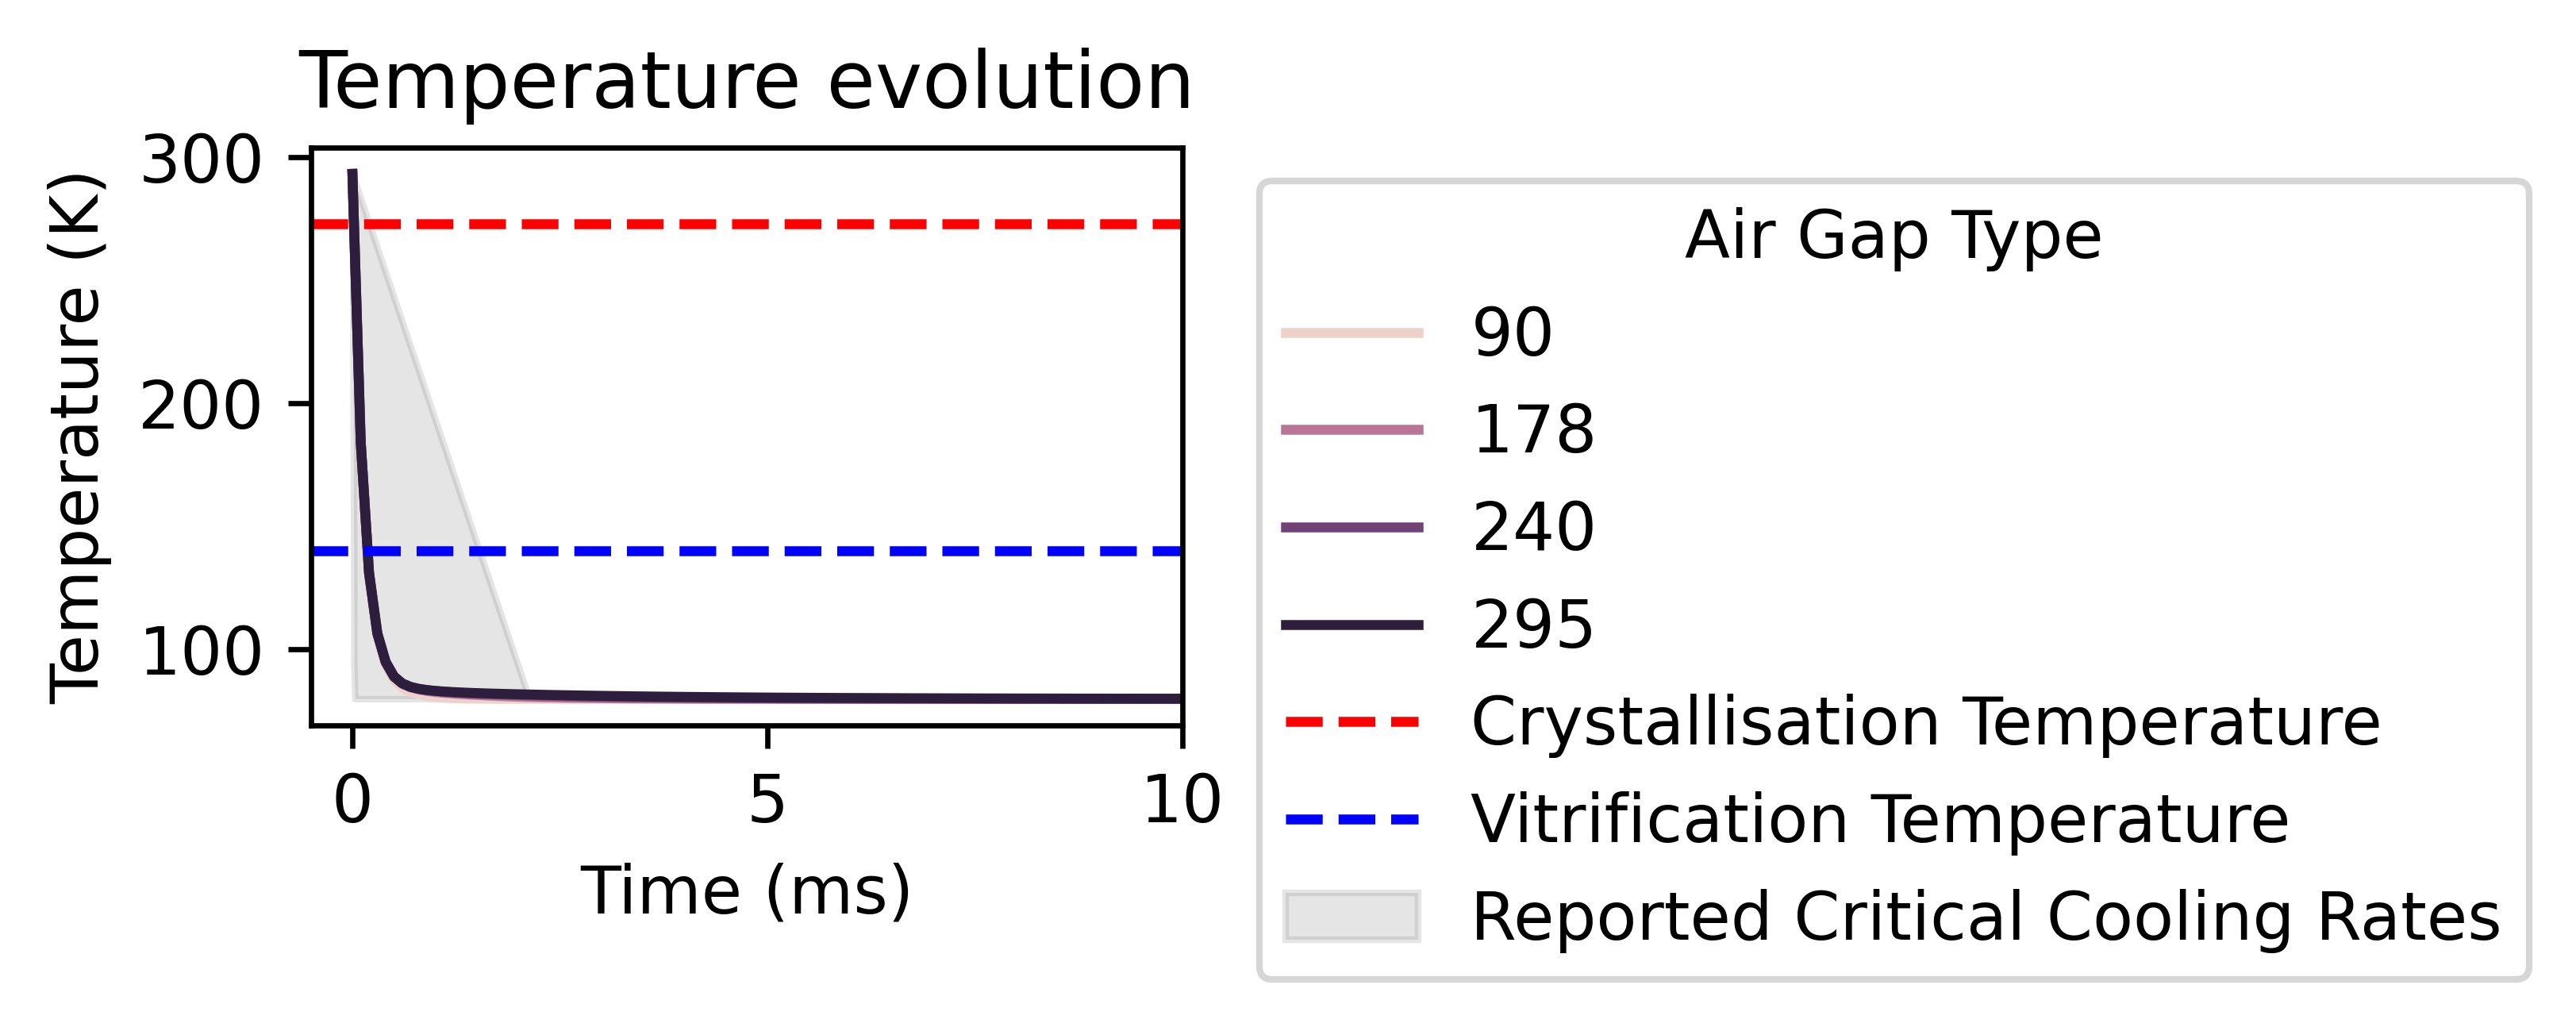

In [20]:
import seaborn as sns
#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
#sns.lineplot(data=comsol_data_symmetric, x="Time (ms)", y="Temperature (K)", hue='Air Gap Thickness (um)', color='orange')
sns.lineplot(data=comsol_data_asymmetric, x="Time (ms)", y="Temperature (K)", hue='Air Gap Thickness (um)', color='purple')

plt.title('Temperature evolution')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
#plt.plot(times_array * 1e3, temperature_profile_with_min_ccr, color='grey', linestyle='-', label='Min Critical Cooling Rate')
#plt.plot(times_array * 1e3, temperature_profile_with_max_ccr, color='grey', linestyle='-', label='Max Critical Cooling Rate')
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.xlim(-0.5, 10)
plt.legend(title='Air Gap Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "asymmetric_temperature_evolution_comsol.pdf"), bbox_inches='tight')

In [21]:
h = 10000
BiotNumber = h * gap_thickness["cryochip"] / k
print(f"Biot Number for air gap thickness {gap_thickness['cryochip']} m: {BiotNumber:.4f}")

Biot Number for air gap thickness 9.5e-05 m: 54.7279


In [22]:
import pandas as pd

# comsol plots from 3D simulations 
insulated_results_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/comsol/insulation_water_and_copper_temperature.csv"
insulated_results_effective_properties_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/comsol/grid_mesh_temperature_with_top_50nm.csv"
insulated_results_carbon_properties_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/comsol/isolated_water_and_carbon_temperatures_using_carbon_properties.csv"
insulated_results_gold_properties_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/comsol/grid_mesh_temperature_using_gold_top_50nm.csv"
contact_results_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/comsol/contact_water_and_copper_temperatures_moving_boundary_50nm.csv"

insulated_results_water_properties = pd.read_csv(insulated_results_path, sep=",", header=[4])
contact_results = pd.read_csv(contact_results_path, sep=",", header=[4])
insulated_results_effective_properties = pd.read_csv(insulated_results_effective_properties_path, sep=",", header=[4])
insulated_results_carbon_properties = pd.read_csv(insulated_results_carbon_properties_path, sep=",", header=[4])
insulated_results_gold_properties = pd.read_csv(insulated_results_gold_properties_path, sep=",", header=[4])

insulated_results_water_properties.columns = ["Time (ms)", "Temperature point", "Temperature copper corner (K)", "Water Temperature (K)", "Copper Temperature (K)"]
insulated_results_effective_properties.columns = ["Time (ms)", "Temperature point", "Temperature copper corner (K)", "Film Temperature (bottom) (K)", "Copper Temperature (K)", "Film Temperature (center) (K)", "Film Temperature (top) (K)"]
insulated_results_carbon_properties.columns = ["Time (ms)", "Temperature point", "Temperature copper corner (K)", "Water Temperature (K)", "Copper Temperature (K)", "Grid center (K)"]
insulated_results_gold_properties.columns = ["Time (ms)", "Temperature point", "Temperature copper corner (K)", "Film Temperature (bottom) (K)", "Copper Temperature (K)", "Film Temperature (center) (K)", "Film Temperature (top) (K)"]
contact_results.columns = ["Time (ms)", "Film Temperature (center) (K)", "Copper Temperature (K)", "Film Temperature (bottom) (K)", "Film Temperature (top) (K)"]

In [23]:
insulated_results_gold_properties.columns

Index(['Time (ms)', 'Temperature point', 'Temperature copper corner (K)',
       'Film Temperature (bottom) (K)', 'Copper Temperature (K)',
       'Film Temperature (center) (K)', 'Film Temperature (top) (K)'],
      dtype='object')

/tmp/ipykernel_4790/2667423607.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


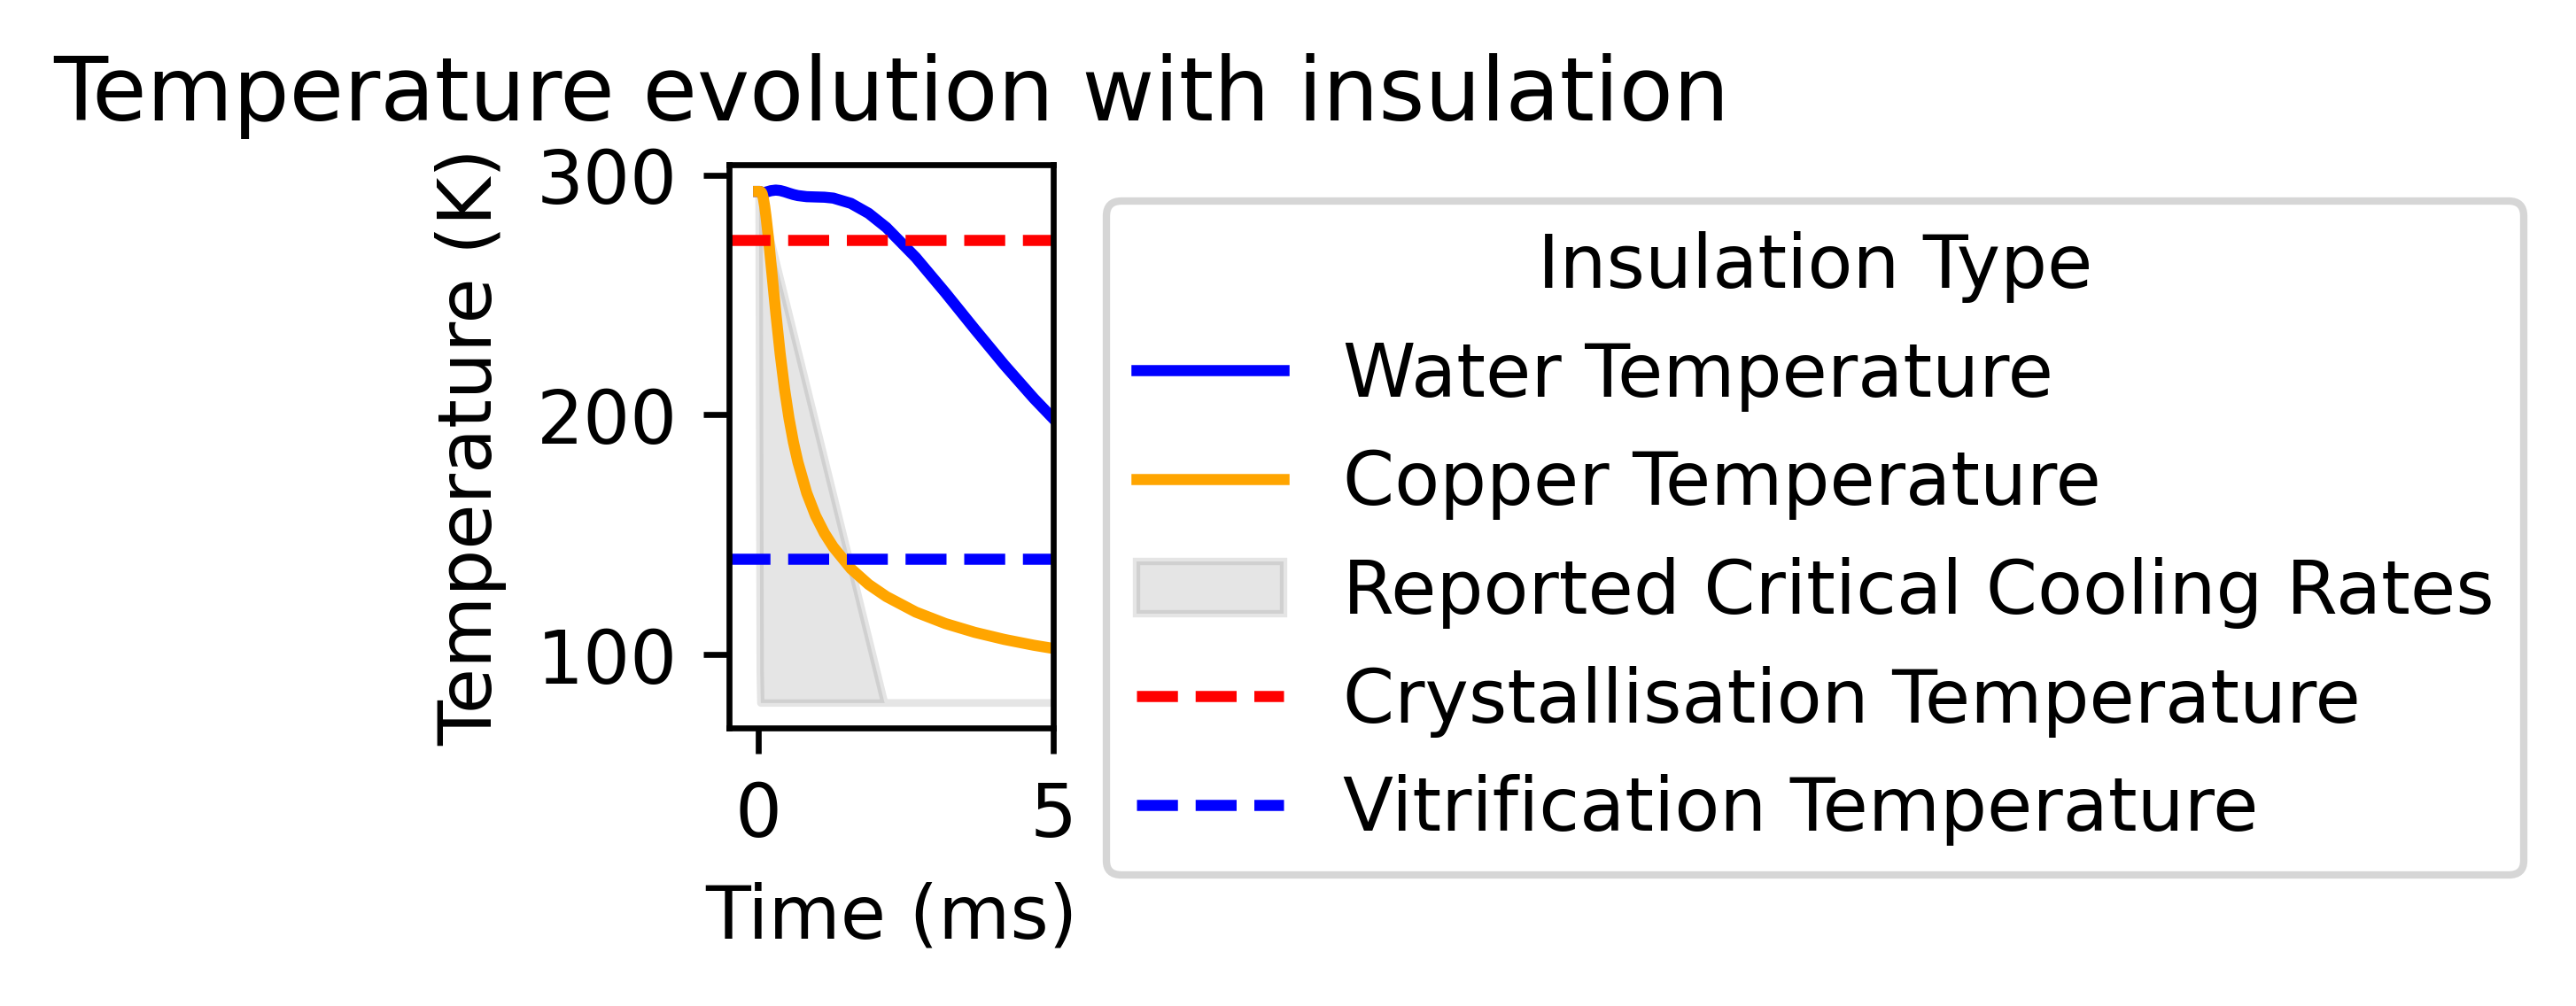

In [24]:
import seaborn as sns
figsize_mm = (20, 35)
figsize_in = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)  # Convert mm to inches
#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
sns.lineplot(data=insulated_results_water_properties, x="Time (ms)", y="Water Temperature (K)", label='Water Temperature', color='blue')
sns.lineplot(data=insulated_results_water_properties, x="Time (ms)", y="Copper Temperature (K)", label='Copper Temperature', color='orange')
# show temperature profiles with reported cooling rates in shaded area
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.title('Temperature evolution with insulation')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
plt.xlim(-0.5, 5)
plt.legend(title='Insulation Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(os.path.join(output_folder, "insulated_temperature_evolution_comsol_water_properties.pdf"), bbox_inches='tight')

/tmp/ipykernel_4790/2024644894.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


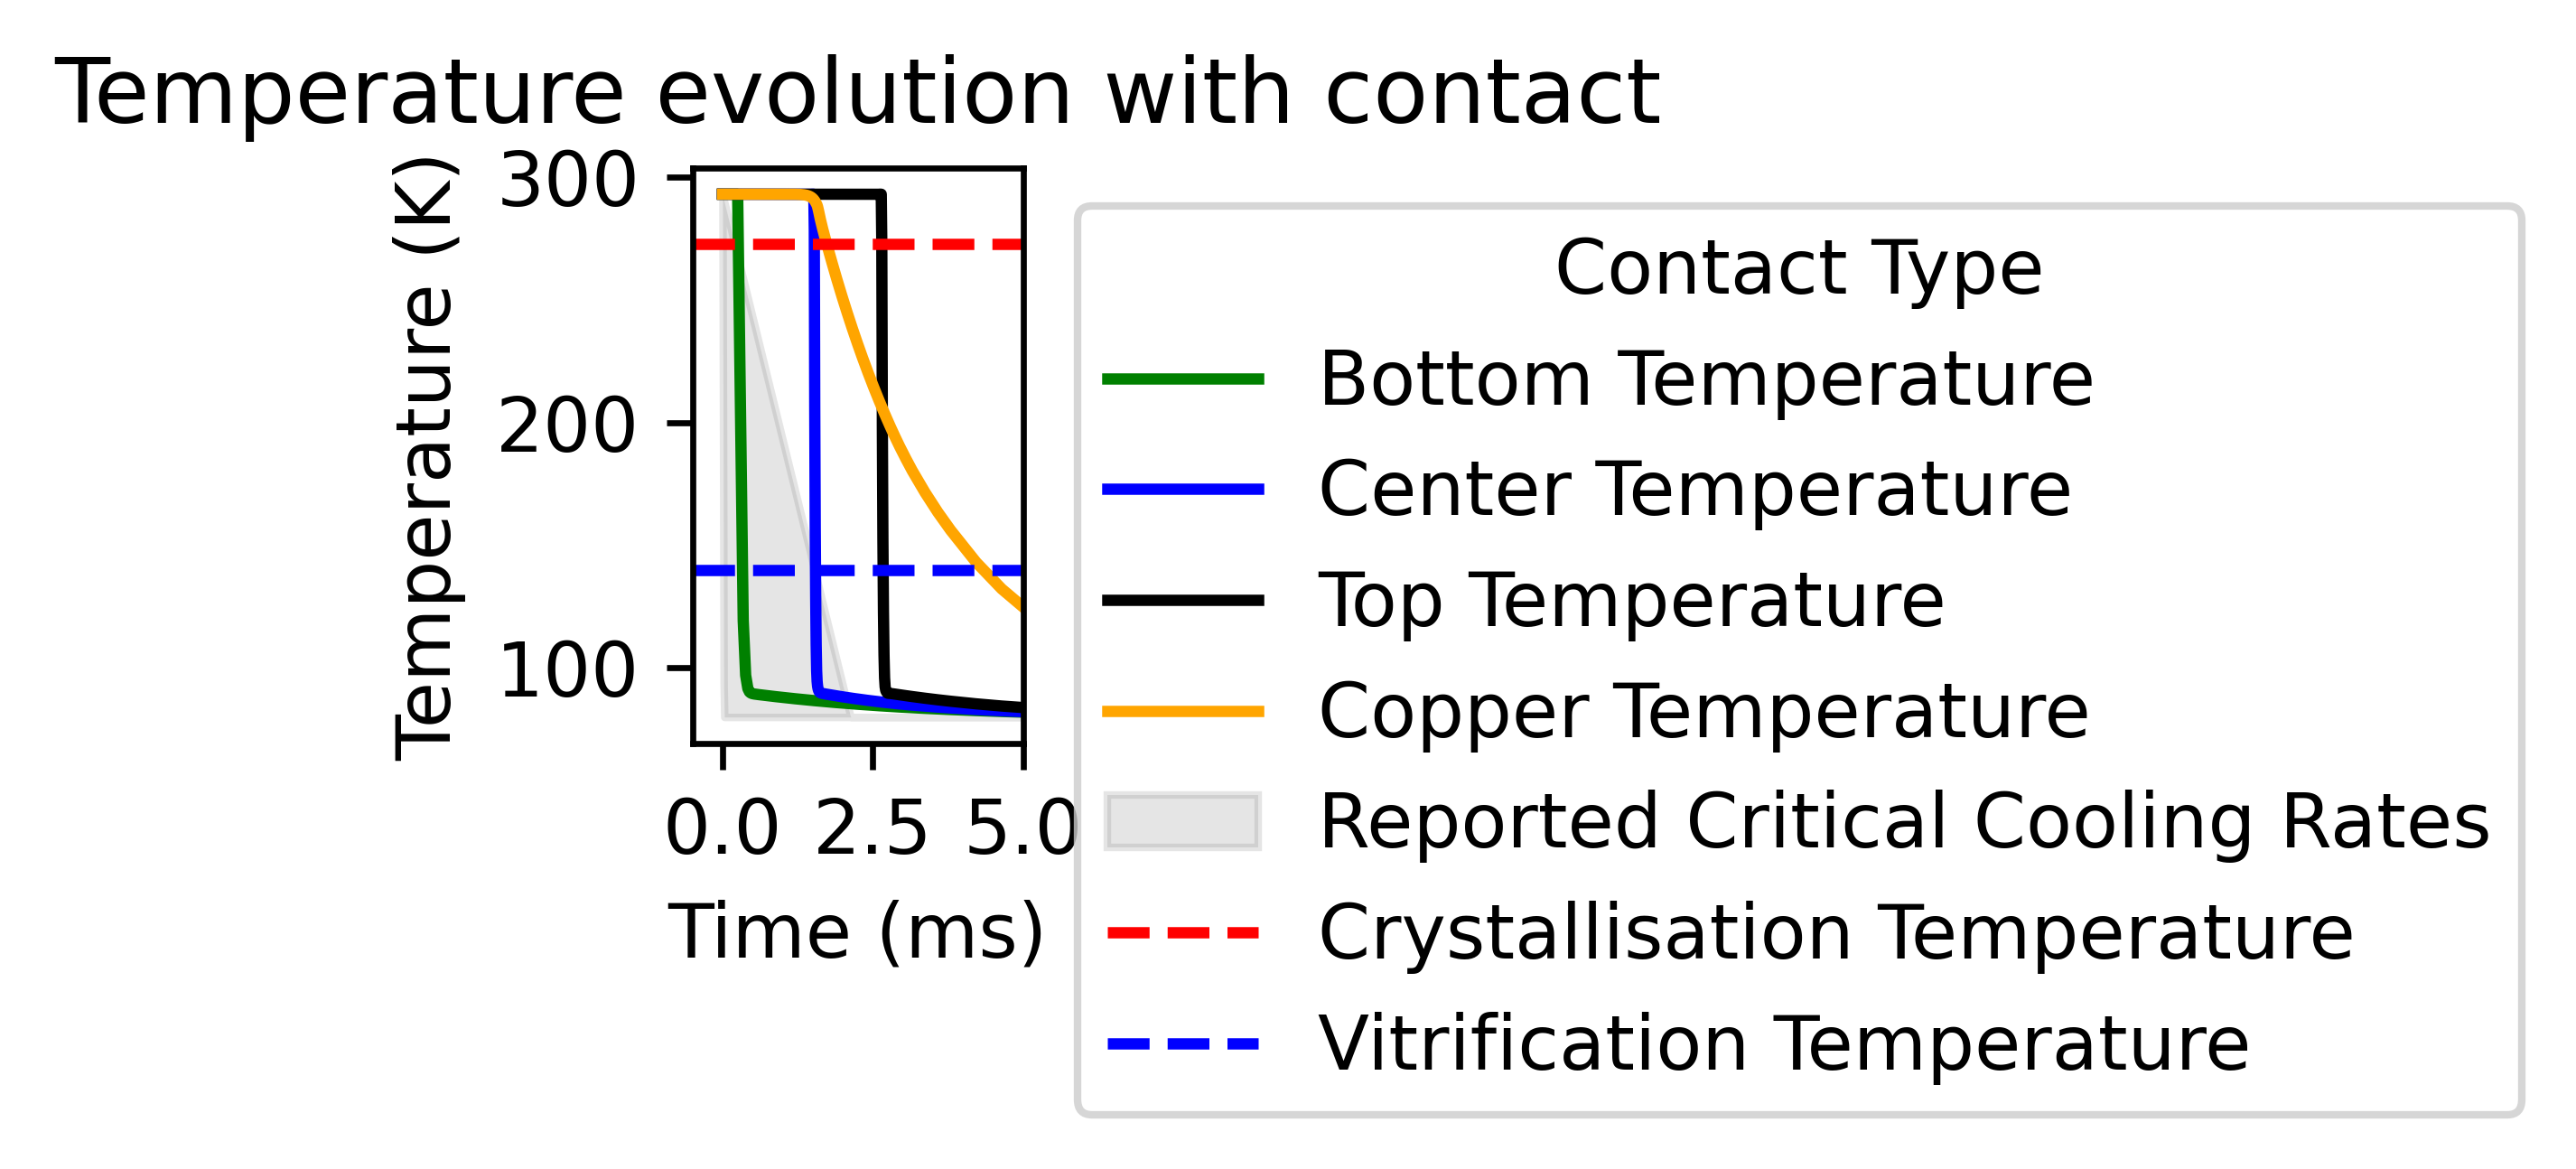

In [25]:
#with temporary_rcparams(rcParams):
# cap max temperature to initial temperature for better visualization
def cap_max_temp_df(df, temp_columns):
    max_temp = 293.15
    df_capped = df.copy()
    for col in temp_columns:
        df_capped[col] = df_capped[col].clip(upper=max_temp)
    return df_capped
temp_columns = ["Film Temperature (center) (K)", "Copper Temperature (K)", "Film Temperature (bottom) (K)", "Film Temperature (top) (K)"]
contact_results_capped = cap_max_temp_df(contact_results, temp_columns)


plt.figure(figsize=figsize_in, dpi=600)
sns.lineplot(data=contact_results_capped, x="Time (ms)", y="Film Temperature (bottom) (K)", label='Bottom Temperature', color='green')
sns.lineplot(data=contact_results_capped, x="Time (ms)", y="Film Temperature (center) (K)", label='Center Temperature', color='blue')
sns.lineplot(data=contact_results_capped, x="Time (ms)", y="Film Temperature (top) (K)", label='Top Temperature', color='black')
sns.lineplot(data=contact_results_capped, x="Time (ms)", y="Copper Temperature (K)", label='Copper Temperature', color='orange')
# show temperature profiles with reported cooling rates in shaded area
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.title('Temperature evolution with contact')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
plt.xlim(-0.5, 5)
plt.xticks([0, 2.5, 5])
plt.legend(title='Contact Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "contact_temperature_evolution_comsol_50nm.pdf"), bbox_inches='tight')

/tmp/ipykernel_4790/4054737395.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


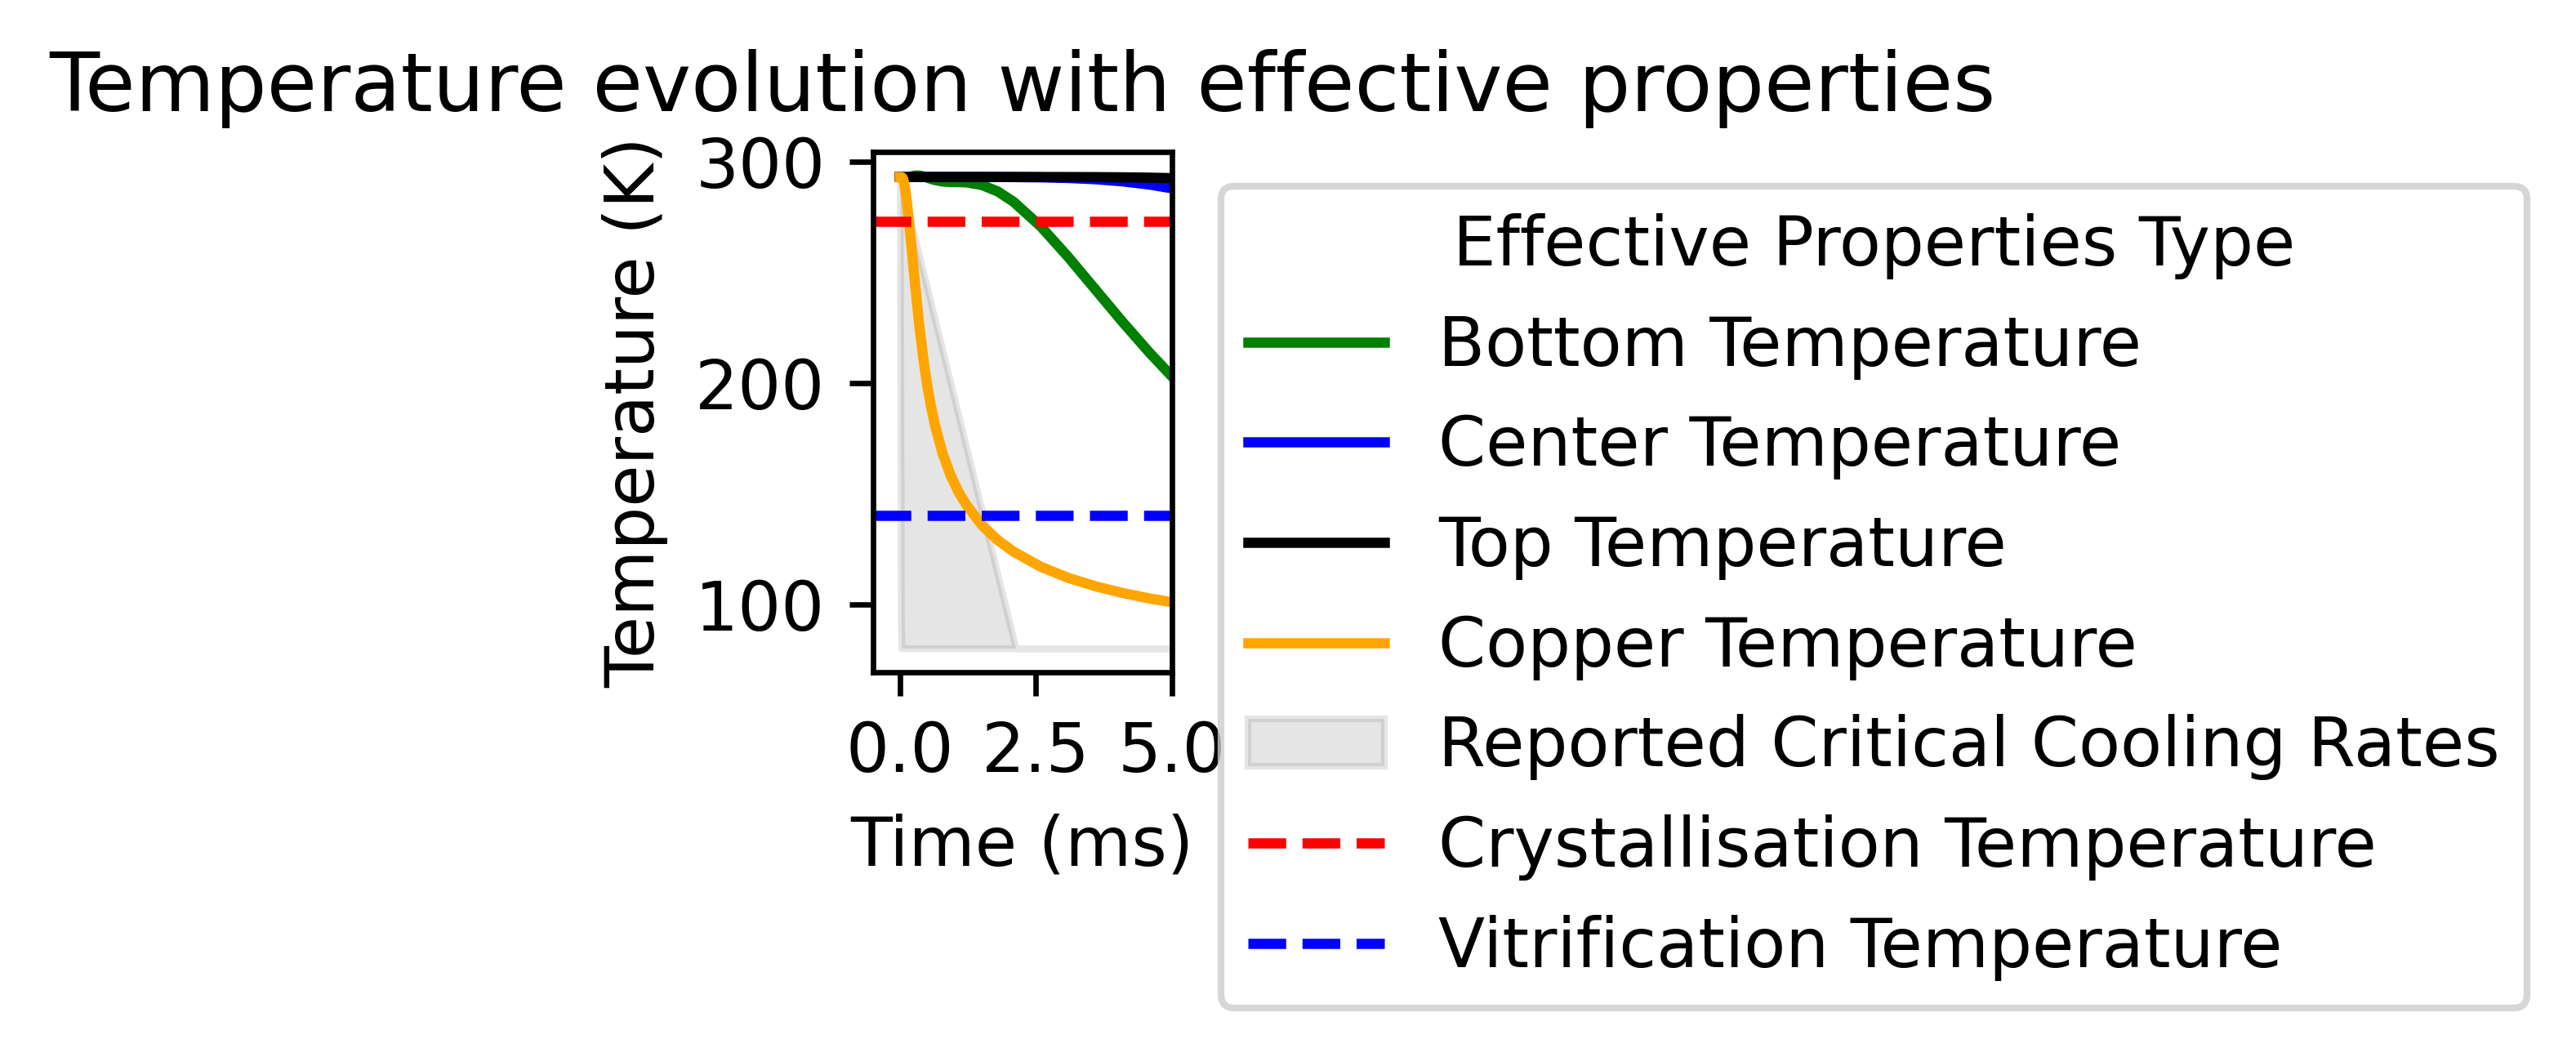

In [26]:
#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
sns.lineplot(data=insulated_results_effective_properties, x="Time (ms)", y="Film Temperature (bottom) (K)", label='Bottom Temperature', color='green')
sns.lineplot(data=insulated_results_effective_properties, x="Time (ms)", y="Film Temperature (center) (K)", label='Center Temperature', color='blue')
sns.lineplot(data=insulated_results_effective_properties, x="Time (ms)", y="Film Temperature (top) (K)", label='Top Temperature', color='black')
sns.lineplot(data=insulated_results_effective_properties, x="Time (ms)", y="Copper Temperature (K)", label='Copper Temperature', color='orange')
#sns.lineplot(data=insulated_results_effective_properties, x="Time (ms)", y="Grid center (K)", label='Grid Center Temperature', color='green')
# show temperature profiles with reported cooling rates in shaded area
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.title('Temperature evolution with effective properties')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
plt.xlim(-0.5, 5)
plt.xticks([0, 2.5, 5])

plt.legend(title='Effective Properties Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "effective_properties_temperature_evolution_comsol_50nm.pdf"), bbox_inches='tight')

/tmp/ipykernel_4790/453921125.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


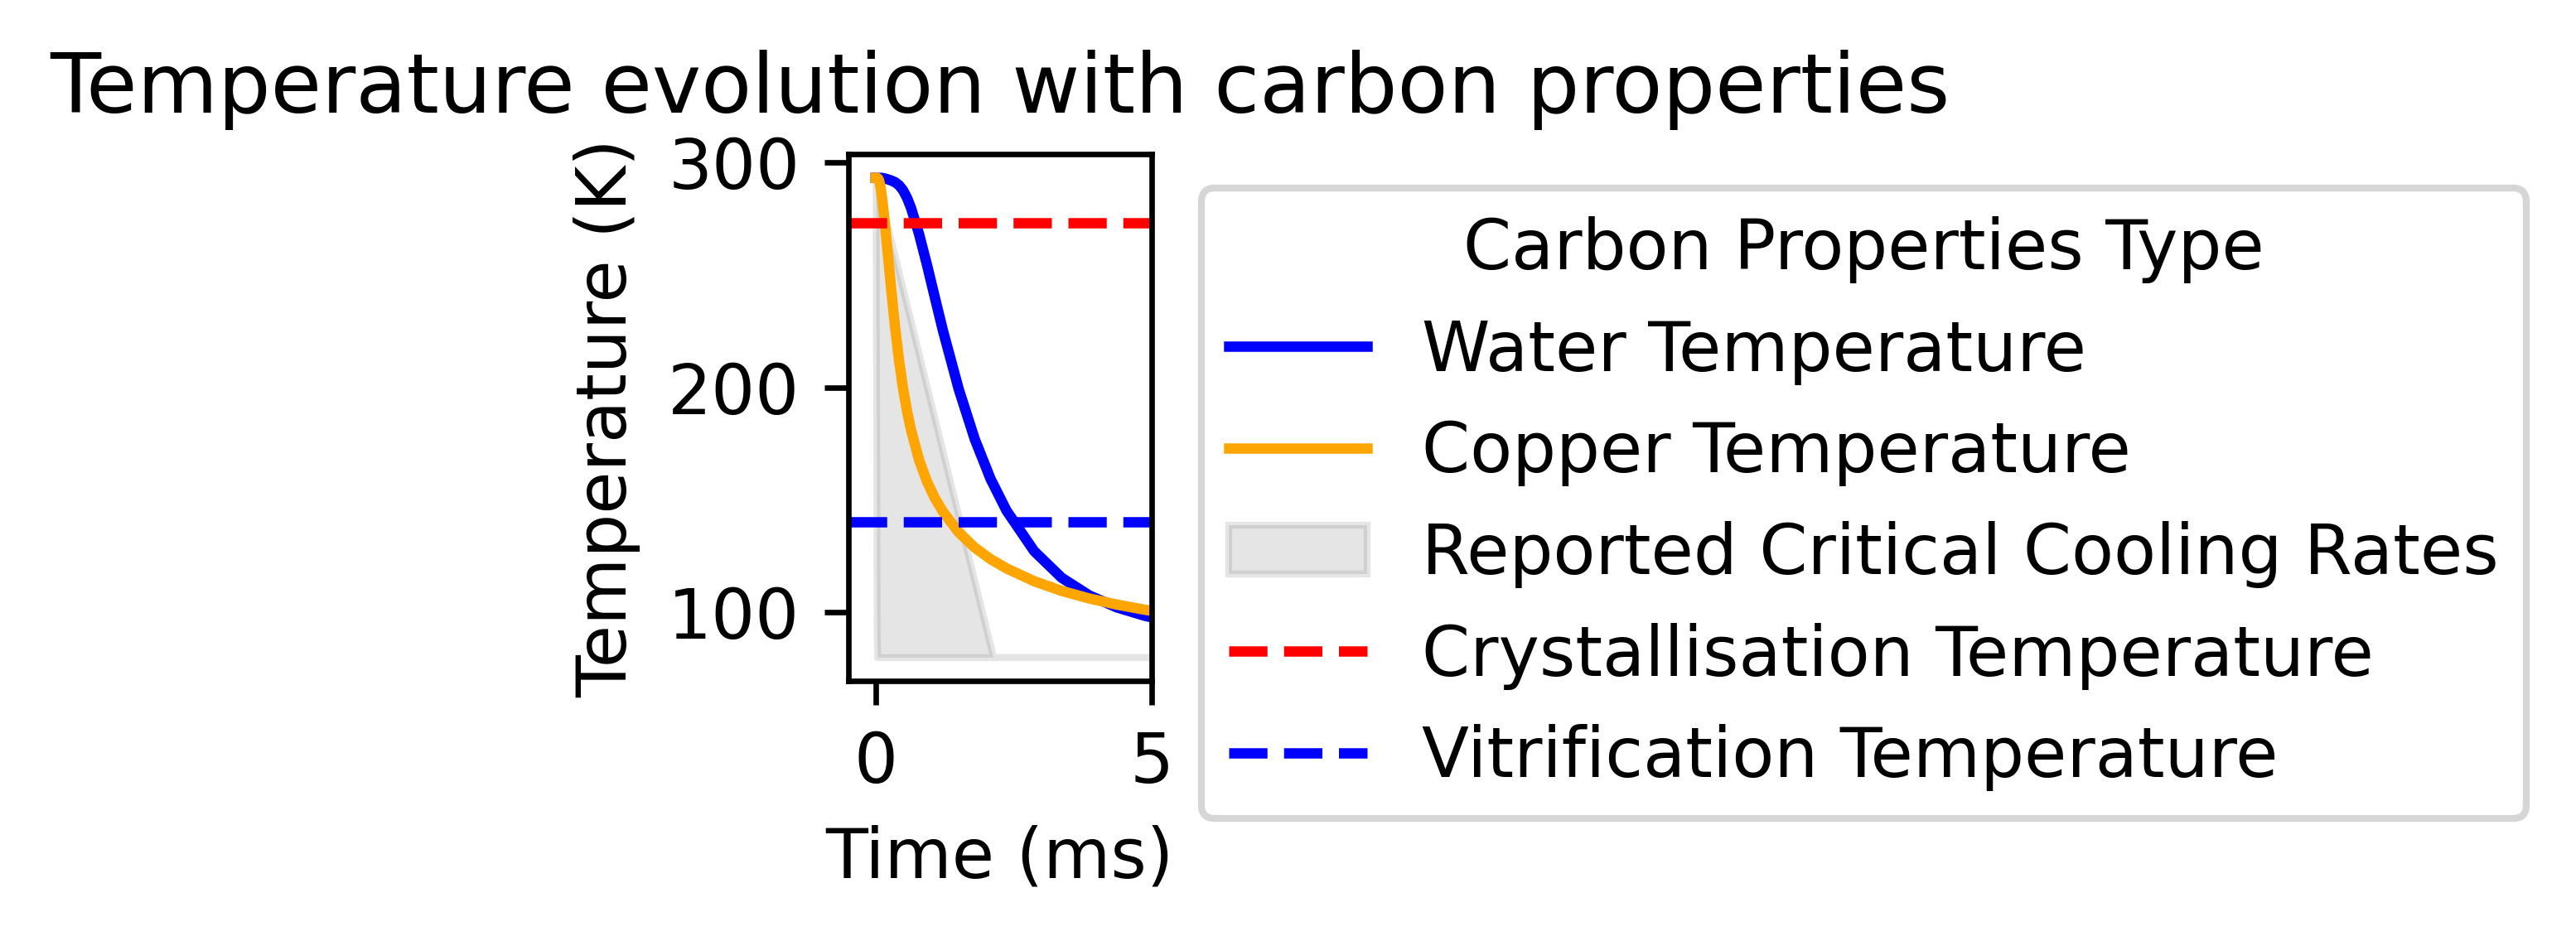

In [27]:
#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
sns.lineplot(data=insulated_results_carbon_properties, x="Time (ms)", y="Water Temperature (K)", label='Water Temperature', color='blue')
sns.lineplot(data=insulated_results_carbon_properties, x="Time (ms)", y="Copper Temperature (K)", label='Copper Temperature', color='orange')
#sns.lineplot(data=insulated_results_carbon_properties, x="Time (ms)", y="Grid center (K)", label='Grid Center Temperature', color='green')
# show temperature profiles with reported cooling rates in shaded area
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.title('Temperature evolution with carbon properties')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
plt.xlim(-0.5, 5)
plt.legend(title='Carbon Properties Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
    #plt.savefig(os.path.join(output_folder, "carbon_properties_temperature_evolution_comsol.pdf"), bbox_inches='tight')


In [ ]:
grid_mesh_temperature_evolution_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/comsol/grid_mesh_temperature.csv"
grid_mesh_temperature_using_gold_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/comsol/grid_mesh_temperature_using_gold.csv"
grid_mesh_temperature_evolution = pd.read_csv(grid_mesh_temperature_evolution_path, sep=",", header=[4])
grid_mesh_temperature_using_gold = pd.read_csv(grid_mesh_temperature_using_gold_path, sep=",", header=[4])
grid_mesh_temperature_evolution.columns = ["Time (ms)", "Temperature point", "Temperature [K]"]
grid_mesh_temperature_using_gold.columns = ["Time (ms)", "Temperature point", "Temperature [K]"]

In [ ]:
with temporary_rcparams(rcParams):
    plt.figure(figsize=figsize_in, dpi=600)
    sns.lineplot(data=grid_mesh_temperature_evolution, x="Time (ms)", y="Temperature [K]", label='Grid Mesh Temperature', color='blue')
    sns.lineplot(data=grid_mesh_temperature_using_gold, x="Time (ms)", y="Temperature [K]", label='Grid Mesh Temperature with Gold', color='orange')
    
    # show temperature profiles with reported cooling rates in shaded area
    plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
    plt.title('Grid Mesh Temperature Evolution')
    plt.xlabel('Time (ms)')
    plt.ylabel('Temperature (K)')
    plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
    plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
    plt.xlim(-0.5, 5)
    plt.legend(title='Grid Mesh Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(os.path.join(output_folder, "grid_mesh_temperature_evolution_comsol.pdf"), bbox_inches='tight')

/tmp/ipykernel_4790/3266678636.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


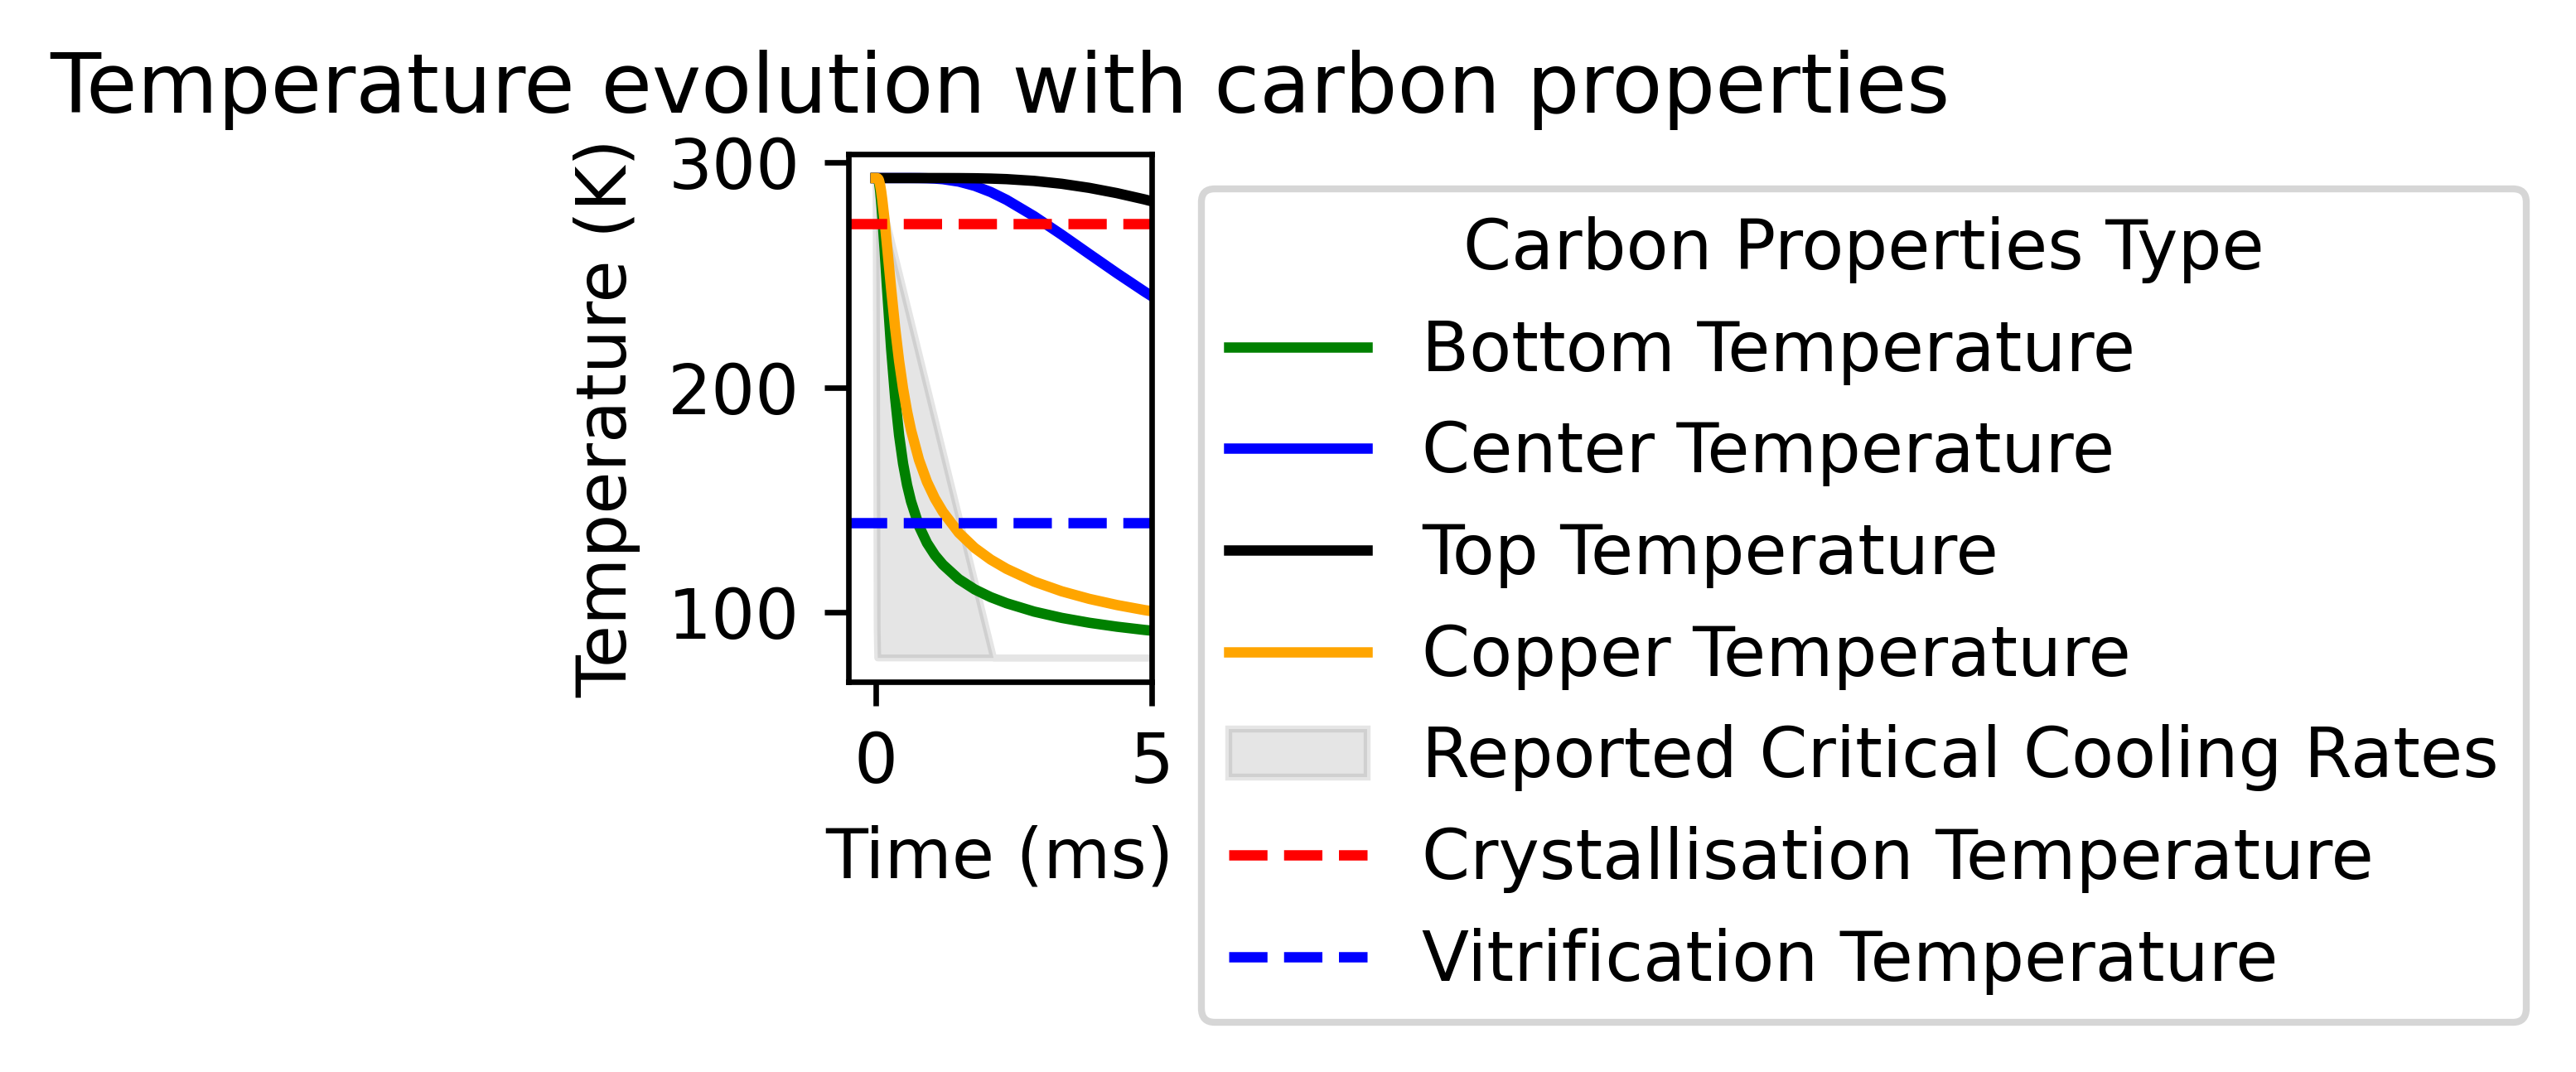

In [29]:
#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
sns.lineplot(data=insulated_results_gold_properties, x="Time (ms)", y="Film Temperature (bottom) (K)", label='Bottom Temperature', color='green')
sns.lineplot(data=insulated_results_gold_properties, x="Time (ms)", y="Film Temperature (center) (K)", label='Center Temperature', color='blue')
sns.lineplot(data=insulated_results_gold_properties, x="Time (ms)", y="Film Temperature (top) (K)", label='Top Temperature', color='black')
sns.lineplot(data=insulated_results_gold_properties, x="Time (ms)", y="Copper Temperature (K)", label='Copper Temperature', color='orange')
#sns.lineplot(data=insulated_results_carbon_properties, x="Time (ms)", y="Grid center (K)", label='Grid Center Temperature', color='green')
# show temperature profiles with reported cooling rates in shaded area
plt.fill_between(times_array * 1e3, temperature_profile_with_min_ccr, temperature_profile_with_max_ccr, color='grey', alpha=0.2, label='Reported Critical Cooling Rates')
plt.title('Temperature evolution with carbon properties')
plt.xlabel('Time (ms)')
plt.ylabel('Temperature (K)')
plt.axhline(crystallisation_temp, color='red', linestyle='--', label='Crystallisation Temperature')
plt.axhline(vitrification_temp, color='blue', linestyle='--', label='Vitrification Temperature')
plt.xlim(-0.5, 5)
plt.legend(title='Carbon Properties Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "temperature_evolution_gold_film.pdf"), bbox_inches='tight')
